In [54]:
import seaborn as sns
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

save_path = Path("diagrams/soft_mrs_analysis")
save_path.mkdir(exist_ok=True)

In [55]:
result_path = Path("../thesis_results/soft_mrs_analysis")
# methods_list = ["uniform","psa", "kmm", "mrs-forest", "fw-mrs-temperature",  "fw-mrs-temperature-svm", "soft-mrs-linear", "soft-mrs-exponential"]
# bias_types = ["less_negative_class", "less_positive_class", "mean_difference",  "none"]
bias_types = ["none"]
less_bias_strengths = ["0.1"]
# mean_bias_strengthts = ["0.8", "0.9"]
mean_bias_strengthts = ["0.8"]
weight_types = ["linear", "exponential"]
# datasets = ["folktables_employment", "folktables_income", "hr_analytics", "breast_cancer", "loan_prediction", 
# "gbs_allensbach", "gbs_gesis", "gbs_allensbach"]
datasets = ["gbs_allensbach"]

In [56]:
dict_list = []

for dataset in datasets:
    for bias_type in bias_types:
        if bias_type == "mean_difference":
            bias_strengths = mean_bias_strengthts
        else : 
            bias_strengths = less_bias_strengths
        for bias_strength in bias_strengths:
            for weight_type in weight_types:
                soft_mrs_analysis_file_name = result_path / weight_type / dataset / bias_type /\
                        bias_strength/ "soft_mrs" 
                soft_mrs_analysis_mmd = pd.read_json(str(soft_mrs_analysis_file_name / "mmds/mmds.json"), 
                                                        orient="records", typ="series", convert_axes=False)

                soft_mrs_analysis_relative_bias = pd.read_json(str(soft_mrs_analysis_file_name / "relative_bias/relative_biases.json"), 
                                                        orient="records", typ="series", convert_axes=False)
                soft_mrs_analysis_aurocs = pd.read_json(str(soft_mrs_analysis_file_name / "aurocs/aurocs.json"), 
                                                        orient="records", typ="series", convert_axes=False)
                soft_mrs_analysis_wasserstein = pd.read_json(str(soft_mrs_analysis_file_name / "wassersteins/wassersteins.json"), 
                                                        orient="records", typ="series", convert_axes=False)
                dict_list.append(
                    {
                        "Data Set": dataset,
                        "Weight Function": weight_type,
                        "bias_type": bias_type,
                        "bias_strength": bias_strength,
                        "MMDs": soft_mrs_analysis_mmd.values,
                        "Relative Bias": soft_mrs_analysis_relative_bias.values,
                        "AUROC": soft_mrs_analysis_aurocs,
                        "Wasserstein": soft_mrs_analysis_wasserstein,
                    }
                                )
result_df = pd.DataFrame(data=dict_list)

In [57]:
for dataset in datasets:
    for bias_type in bias_types:
        if bias_type == "mean_difference":
            bias_strengths = mean_bias_strengthts
        else : 
            bias_strengths = less_bias_strengths
        for bias_strength in bias_strengths:
            linear_mmd = result_df.loc[(result_df["Weight Function"]=="linear") & (result_df["bias_type"]==bias_type) & 
                                                    (result_df["bias_strength"]==bias_strength) & 
                                                    (result_df["Data Set"]==dataset)]["MMDs"].values[0]
            linear_relative_bias = result_df.loc[(result_df["Weight Function"]=="linear") & (result_df["bias_type"]==bias_type) & 
                                                    (result_df["bias_strength"]==bias_strength) & 
                                                    (result_df["Data Set"]==dataset)]["Relative Bias"].values[0]
            linear_aurocs = result_df.loc[(result_df["Weight Function"]=="linear") & (result_df["bias_type"]==bias_type) & 
                                                    (result_df["bias_strength"]==bias_strength) & 
                                                    (result_df["Data Set"]==dataset)]["AUROC"].values[0]
            linear_wassersteins = result_df.loc[(result_df["Weight Function"]=="linear") & (result_df["bias_type"]==bias_type) & 
                                                    (result_df["bias_strength"]==bias_strength) & 
                                                    (result_df["Data Set"]==dataset)]["Wasserstein"].values[0]
            
            exponential_mmd = result_df.loc[(result_df["Weight Function"]=="exponential") & (result_df["bias_type"]==bias_type) & 
                                                    (result_df["bias_strength"]==bias_strength) & 
                                                    (result_df["Data Set"]==dataset)]["MMDs"].values[0]
            exponential_relative_bias = result_df.loc[(result_df["Weight Function"]=="exponential") & (result_df["bias_type"]==bias_type) & 
                                                    (result_df["bias_strength"]==bias_strength) & 
                                                    (result_df["Data Set"]==dataset)]["Relative Bias"].values[0]
            exponential_aurocs = result_df.loc[(result_df["Weight Function"]=="exponential") & (result_df["bias_type"]==bias_type) & 
                                                    (result_df["bias_strength"]==bias_strength) & 
                                                    (result_df["Data Set"]==dataset)]["AUROC"].values[0]
            exponential_wassersteins = result_df.loc[(result_df["Weight Function"]=="exponential") & (result_df["bias_type"]==bias_type) & 
                                                    (result_df["bias_strength"]==bias_strength) & 
                                                    (result_df["Data Set"]==dataset)]["Wasserstein"].values[0]

In [58]:
linear_mmd = np.concatenate(linear_mmd).reshape(len(linear_mmd),*np.shape(linear_mmd[0]))
linear_aurocs = np.concatenate(linear_aurocs).reshape(len(linear_aurocs),*np.shape(linear_aurocs[0]))
linear_relative_bias = np.concatenate(linear_relative_bias).reshape(len(linear_relative_bias),*np.shape(linear_relative_bias[0]))
linear_wassersteins = np.concatenate(linear_wassersteins).reshape(len(linear_wassersteins),*np.shape(linear_wassersteins[0]))

exponential_mmd = np.concatenate(exponential_mmd).reshape(len(exponential_mmd),*np.shape(exponential_mmd[0]))
exponential_aurocs = np.concatenate(exponential_aurocs).reshape(len(exponential_mmd),*np.shape(exponential_aurocs[0]))
exponential_relative_bias = np.concatenate(exponential_relative_bias).reshape(len(exponential_relative_bias),*np.shape(exponential_relative_bias[0]))
exponential_wassersteins = np.concatenate(exponential_wassersteins).reshape(len(exponential_wassersteins),*np.shape(exponential_wassersteins[0]))

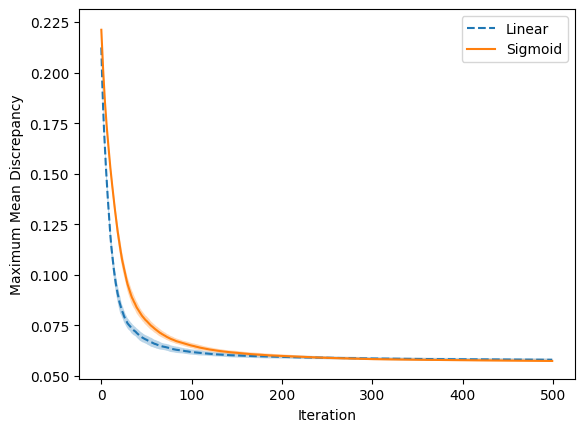

In [59]:
mean_linear_mmd = np.mean(linear_mmd, axis=0)
std_linear_mmd = np.std(linear_mmd, axis=0)
mean_exponential_mmd = np.mean(exponential_mmd, axis=0)
std_exponential_mmd = np.std(exponential_mmd, axis=0)

sns.lineplot(mean_linear_mmd, label="Linear", linestyle="dashed").set(xlabel="Iteration", ylabel="Maximum Mean Discrepancy")
plt.fill_between(x= list(range(len(mean_linear_mmd))), y1=mean_linear_mmd + std_linear_mmd, 
                 y2=mean_linear_mmd - std_linear_mmd, alpha=0.3)
sns.lineplot(mean_exponential_mmd, label="Sigmoid")
plt.fill_between(x= list(range(len(mean_exponential_mmd))), y1=mean_exponential_mmd + std_exponential_mmd, 
                 y2=mean_exponential_mmd - std_exponential_mmd, alpha=0.3)
plt.savefig(save_path / "mmds.pdf")

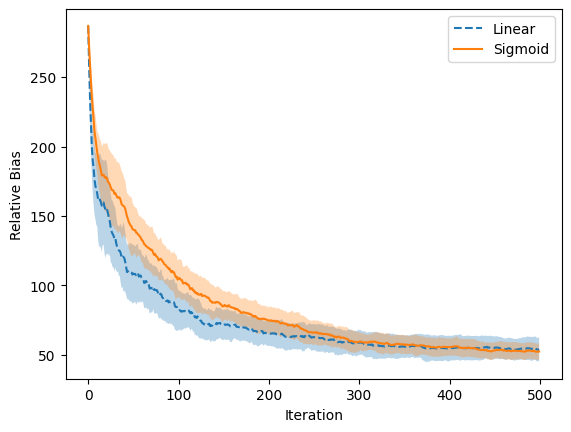

In [60]:
mean_linear_relative_bias = np.mean(linear_relative_bias, axis=0)
std_linear_relative_bias = np.std(linear_relative_bias, axis=0)
mean_exponential_relative_bias = np.mean(exponential_relative_bias, axis=0)
std_exponential_relative_bias = np.std(exponential_relative_bias, axis=0)

sns.lineplot(mean_linear_relative_bias, label="Linear", linestyle="dashed").set(xlabel="Iteration", ylabel="Relative Bias")
plt.fill_between(x= list(range(len(mean_linear_relative_bias))), y1=mean_linear_relative_bias + std_linear_relative_bias, 
                 y2=mean_linear_relative_bias - std_linear_relative_bias, alpha=0.3)
sns.lineplot(mean_exponential_relative_bias, label="Sigmoid")
plt.fill_between(x= list(range(len(mean_exponential_relative_bias))), y1=mean_exponential_relative_bias + std_exponential_relative_bias, 
                 y2=mean_exponential_relative_bias - std_exponential_relative_bias, alpha=0.3)
plt.savefig(save_path / "relative_bias.pdf")

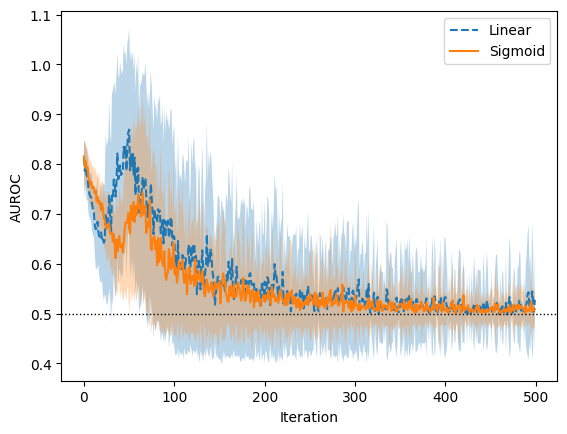

In [61]:
mean_linear_aurocs = np.mean(linear_aurocs, axis=0)
std_linear_aurocs = np.std(linear_aurocs, axis=0)
mean_exponential_aurocs = np.mean(exponential_aurocs, axis=0)
std_exponential_aurocs = np.std(exponential_aurocs, axis=0)

sns.lineplot(mean_linear_aurocs, label="Linear", linestyle="dashed").set(xlabel="Iteration", ylabel="AUROC")
plt.fill_between(x= list(range(len(mean_linear_aurocs))), y1=mean_linear_aurocs + std_linear_aurocs, 
                 y2=mean_linear_aurocs - std_linear_aurocs, alpha=0.3)
sns.lineplot(mean_exponential_aurocs, label="Sigmoid")
plt.axhline(y=0.5, color="black", linestyle="dotted", linewidth=1) 
plt.fill_between(x= list(range(len(mean_exponential_aurocs))), y1=mean_exponential_aurocs + std_exponential_aurocs, 
                 y2=mean_exponential_aurocs - std_exponential_aurocs, alpha=0.3)
plt.savefig(save_path / "aurocs.pdf")

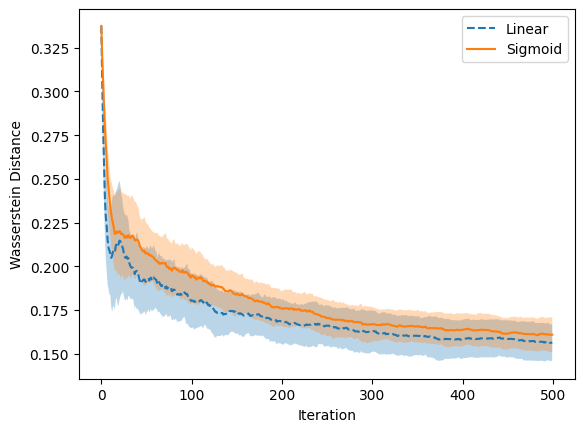

In [62]:
mean_linear_wassersteins = np.mean(linear_wassersteins, axis=0)
std_linear_wassersteins = np.std(linear_wassersteins, axis=0)
mean_exponential_wassersteins = np.mean(exponential_wassersteins, axis=0)
std_exponential_wassersteins = np.std(exponential_wassersteins, axis=0)

sns.lineplot(mean_linear_wassersteins, label="Linear", linestyle="dashed").set(xlabel="Iteration", ylabel="Wasserstein Distance")
plt.fill_between(x= list(range(len(mean_linear_wassersteins))), y1=mean_linear_wassersteins + std_linear_wassersteins, 
                 y2=mean_linear_wassersteins - std_linear_wassersteins, alpha=0.3)
sns.lineplot(mean_exponential_wassersteins, label="Sigmoid")
plt.fill_between(x= list(range(len(mean_exponential_wassersteins))), y1=mean_exponential_wassersteins + std_exponential_wassersteins, 
                 y2=mean_exponential_wassersteins - std_exponential_wassersteins, alpha=0.3)
plt.savefig(save_path / f"wasserstein.pdf")